In [1]:
# import config from paper_figures/ (parent of this notebook's folder)
import sys
from pathlib import Path

try:
    _paper_figures = Path(__file__).resolve().parent.parent
except NameError:
    # Jupyter: __file__ is undefined; cwd is usually paper_figures or pumping/
    _cwd = Path.cwd()
    _paper_figures = _cwd.parent if _cwd.name == "GWMM" else _cwd

sys.path.insert(0, str(_paper_figures))
import utils

In [2]:
import plotly.express as px

In [3]:
INTERVAL = 219

In [ ]:
DOMAIN = "wolf"
OUTLET_X = 18
OUTLET_Y = 21


In [5]:
ensemble_name = "pumping_ensemble"
ensemble_member = "baseline"
baseline = utils.read_simulation_data(ensemble_name, ensemble_member, DOMAIN)
ensemble_member = "pumping_0_01"
drought = utils.read_simulation_data(ensemble_name, ensemble_member, DOMAIN)

FileNotFoundError: [Errno 2] No such file or directory: '/glade/derecho/scratch/bwest/drought-ensemble/domains/wolf2/processed_full_runs/pumping_ensemble/baseline/file_locations.json'

In [ ]:
baseline.info()

xarray.Dataset {
dimensions:
	time = 122640 ;
	z = 10 ;
	y = 41 ;
	x = 78 ;

variables:
	float64 pressure(time, z, y, x) ;
	float64 saturation(time, z, y, x) ;
	float64 evaptrans(time, z, y, x) ;
	float64 overland_bc_flux(time, y, x) ;
	float64 mask(time, z, y, x) ;
	float64 mannings(time, y, x) ;
	float64 porosity(time, z, y, x) ;
	float64 specific_storage(time, z, y, x) ;
	float64 DZ_Multiplier(time, z, y, x) ;
	float64 slopex(time, y, x) ;
	float64 slopey(time, y, x) ;
	float64 perm_x(time, z, y, x) ;
	float64 perm_y(time, z, y, x) ;
	float64 perm_z(time, z, y, x) ;
	float64 overland_flow(time, y, x) ;
	float64 storage(time, z, y, x) ;
	float64 time(time) ;

// global attributes:
}

In [ ]:
# baseline.overland_flow.isel(x=OUTLET_X, y=OUTLET_Y, time=slice(0, None, INTERVAL)).plot()

In [ ]:
# drought.overland_flow.isel(x=OUTLET_X, y=OUTLET_Y, time=slice(0, None, INTERVAL)).plot()

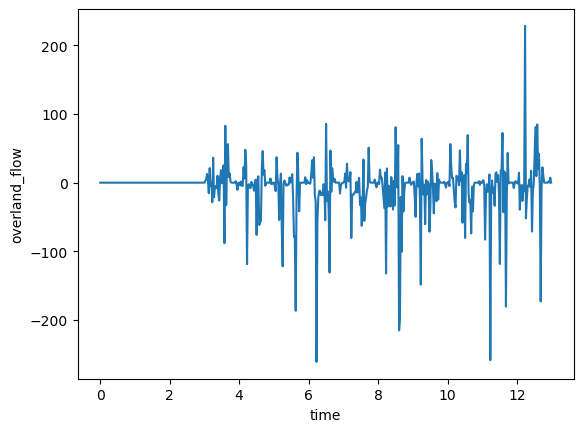

In [ ]:
# plot the difference between the two
diff = drought.overland_flow - baseline.overland_flow
diff.isel(x=OUTLET_X, y=OUTLET_Y, time=slice(0, None, INTERVAL)).plot()


In [ ]:
storage_deficit = (drought.storage - baseline.storage).sum(dim="x").sum(dim="y").sum(dim="z").isel(time=slice(0, None, INTERVAL))
# storage_deficit.plot()
soil_moisture_deficit = (drought.storage - baseline.storage).isel(z=slice(8, None)).sum(dim="x").sum(dim="y").sum(dim="z").isel(time=slice(0, None, INTERVAL))
deep_root_zone_deficit = (drought.storage - baseline.storage).isel(z=slice(6, 8)).sum(dim="x").sum(dim="y").sum(dim="z").isel(time=slice(0, None, INTERVAL))
confined_zone_deficit = (drought.storage - baseline.storage).isel(z=slice(0, 6)).sum(dim="x").sum(dim="y").sum(dim="z").isel(time=slice(0, None, INTERVAL))
unconfined_zone_deficit = (drought.storage - baseline.storage).isel(z=slice(6, None)).sum(dim="x").sum(dim="y").sum(dim="z").isel(time=slice(0, None, INTERVAL))


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


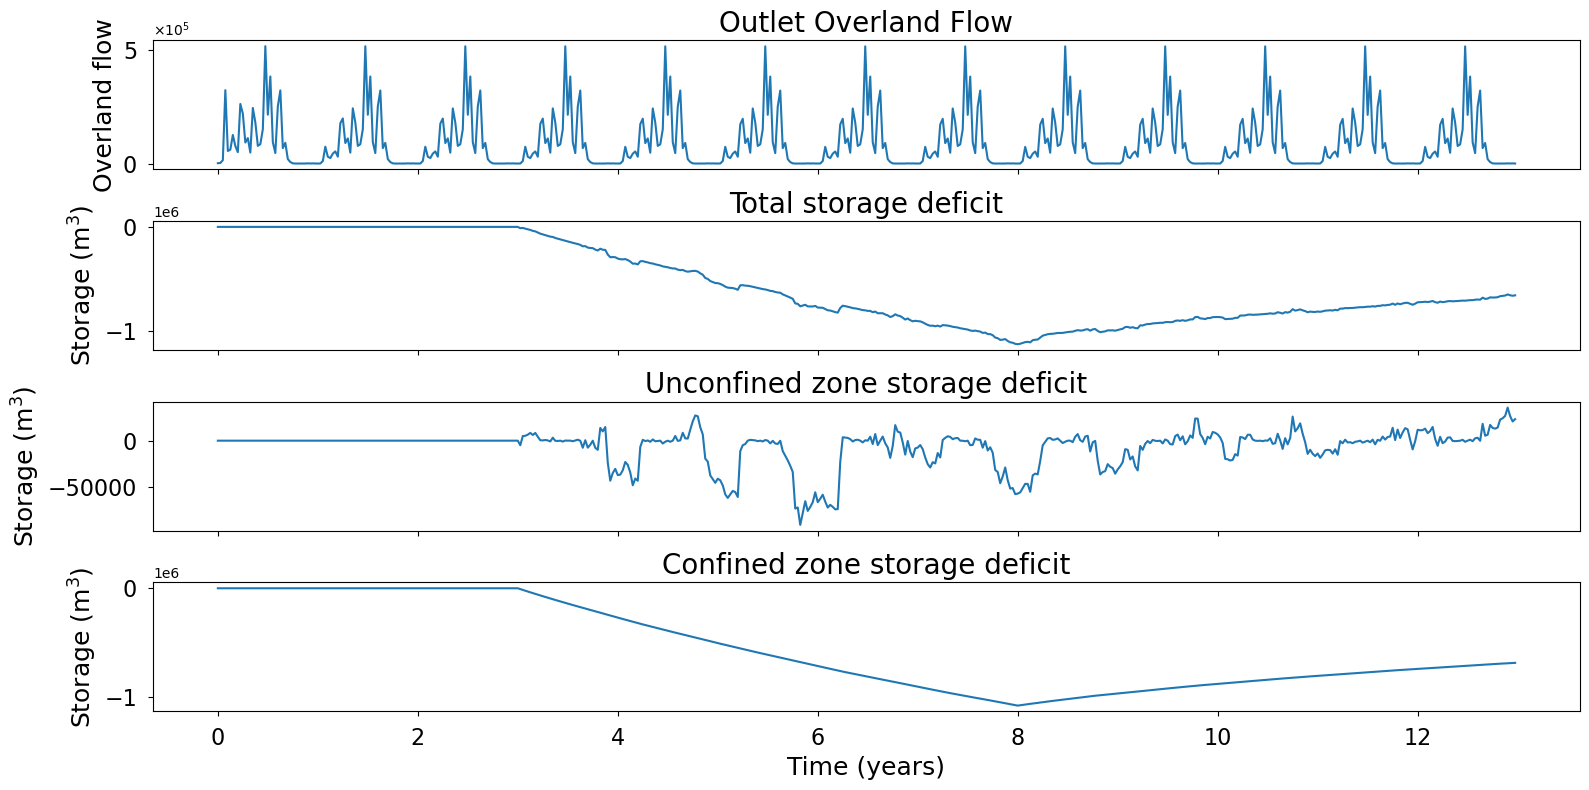

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# Panel 1: Overland flow at outlet (one per year)
overland_flow_drought = drought.overland_flow.isel(x=OUTLET_X, y=OUTLET_Y, time=slice(0, None, INTERVAL))
axes[0].plot(overland_flow_drought["time"], overland_flow_drought, label="Drought")
# axes[0].set_ylim(0, 2.1e5)
axes[0].set_ylabel("Overland flow")
axes[0].set_title("Outlet Overland Flow")
axes[0].legend()
# Make y axis numbers more compact on top plot — use scientific notation and less horizontal space
axes[0].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
axes[0].yaxis.offsetText.set_fontsize(10)

# Panel 2: Storage deficit (one per year)
axes[1].plot(storage_deficit["time"], storage_deficit)
axes[1].set_ylabel("Storage (m$^3$)")
axes[1].set_title("Total storage deficit")

# Panel 4: Unconfined zone water required to recover
axes[2].plot(unconfined_zone_deficit["time"], unconfined_zone_deficit)
# axes[2].set_ylim(-2.3e8, 0.1e8)
axes[2].set_ylabel("Storage (m$^3$)")
axes[2].set_title("Unconfined zone storage deficit")

# Panel 3: Confined zone storage deficit
axes[3].plot(confined_zone_deficit["time"], confined_zone_deficit)
# axes[3].set_ylim(-2.3e8, 0.1e8)
axes[3].set_ylabel("Storage (m$^3$)")
axes[3].set_xlabel("Time (years)")
axes[3].set_title("Confined zone storage deficit")

for ax in axes:
    ax.legend().set_visible(False)

# Make all the fonts larger but avoid overlap

# Set fontsize parameters
label_fontsize = 18
title_fontsize = 20
tick_fontsize = 16
legend_fontsize = 15

for i, ax in enumerate(axes):
    # Axis titles/labels
    ax.title.set_fontsize(title_fontsize)
    ax.xaxis.label.set_fontsize(label_fontsize)
    ax.yaxis.label.set_fontsize(label_fontsize)
    # Tick labels
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize-2)
    # Adjust tick padding to avoid overlap
    ax.xaxis.set_tick_params(pad=8)
    ax.yaxis.set_tick_params(pad=8)
    # Legend font size (if shown)
    leg = ax.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontsize(legend_fontsize)

# Adjust the layout again to help avoid overlap with larger fonts
plt.tight_layout(pad=2.0, rect=[0, 0, 1, 0.97])

# Adjust the figure size to make subplots longer than tall (e.g., 14 inches wide, 8 inches tall)
fig.set_size_inches(16, 8)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)  # Ensure enough space between plots
plt.show()